In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Implementation of MCP Neuron for AND and OR Function.

In [2]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

  state_neuron = []

  # Perform element-wise addition and apply threshold
  for i in range(len(X1)):
    s = X1[i] + X2[i]
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)


  return state_neuron

In [3]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [4]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    state_neuron = []

    # Perform element-wise addition and apply threshold
    for i in range(len(X1)):
      s= X1[i] + X2[i]
      if s>=T:
        state_neuron.append(1)
      else:
        state_neuron.append(0)

    return state_neuron


In [5]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question 1: Limitations of MCP Neuron

Cannot learn from data because it has no training rule.
Uses fixed, manually chosen thresholds.
Works only for very simple logic functions such as AND and OR.
Cannot solve non-linearly separable problems such as XOR.
Does not adapt automatically to new data.
Binary input/output behavior is highly simplified.


Question 2: Can MCP solve XOR?

No. A single MCP neuron cannot solve XOR.
XOR is not linearly separable.
A single threshold neuron cannot separate the two classes with one straight decision boundary.

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI_ML/Week3/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing the Dataset.

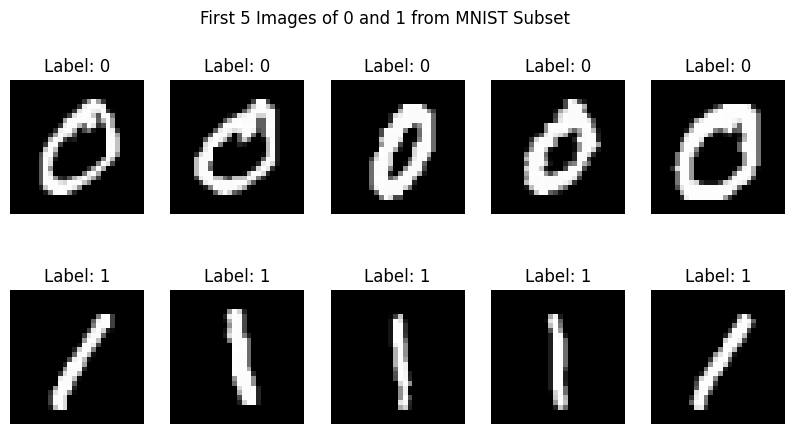

In [9]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [11]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

## Step - 3 - Make a Decision function:

In [12]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [16]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epcoh in range(epochs):
      for i in range(X.shape[0]):
        output = np.dot(X[i],weights) + bias
        y_pred = 1 if output >=0 else 0
        if y_pred != y[i]:
          weights += learning_rate * (y[i] - y_pred) * X[i]
          bias += learning_rate * (y[i] - y_pred)
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all ==y)
    return weights, bias, accuracy

Question 5:
What is the purpose of output = np.dot(X[i], weights) + bias line?

Answer:
This computes the weighted sum of inputs plus the bias for the i-th sample. The perceptron then uses this value in the step activation function to decide whether to output 0 or 1. Essentially, it calculates the “net input” to the neuron.

Question 6:
What happens when the prediction is wrong? How are the weights and bias updated?

Answer:
When the perceptron misclassifies a sample (y_pred != y[i]), the weights and bias are updated using:

weights += learning_rate * (y[i] - y_pred) * X[i]
bias += learning_rate * (y[i] - y_pred)

This nudges the decision boundary so that the neuron will correctly classify the sample next time.

Question 7:
Why is the final accuracy important, and what do you expect it to be?

Answer:
The final accuracy shows how well the perceptron learned to separate the two classes. For linearly separable data like 0 vs 1, we expect accuracy to be close to 1.0 (100%).

## Training the Perceptron

In [18]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [20]:
y_pred = decision_function(X, weights, bias)
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis('off')
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


Question 8:
What does misclassified_idx store, and how is it used in this code?

Answer:
misclassified_idx stores the indices of samples where the predicted label does not match the true label. It is used to visualize the images that were incorrectly classified.

Question 9:
How do you interpret the result if the output is “All images were correctly classified!”?

Answer:
It means the perceptron was able to perfectly separate the two classes (0 and 1) using a linear decision boundary, and there were no errors in classification.

# Perceptron Algorithm for 3 vs 5 Classification.

## Load the Dataset

In [21]:
# Load the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI_ML/Week3/mnist_3_and_5.csv")  # Update path if needed

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


### Viewing the Dataset.

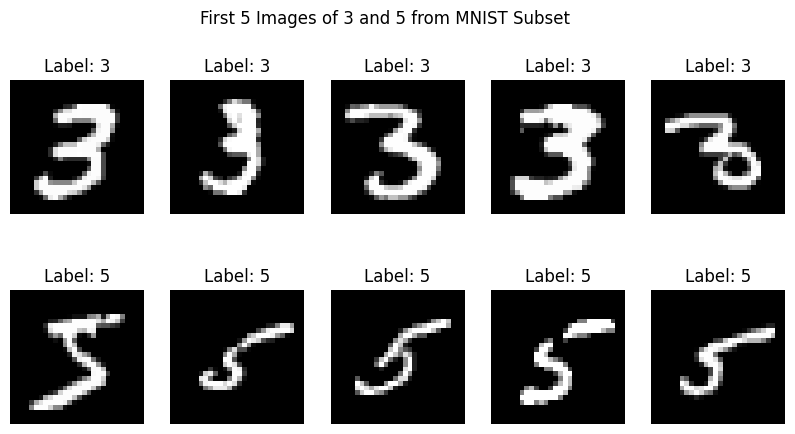

In [22]:
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis('off')

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis('off')

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.show()

### Map Labels to 0 and 1

In [23]:
# Map 3 -> 0, 5 -> 1 for binary classification
y_35_bin = np.where(y_35 == 3, 0, 1)

## Initializing the Weights and Bias:

In [24]:
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs = 100

## Train Perceptron on 3 vs 5

In [25]:
weights_35, bias_35, accuracy_35 = train_perceptron(X_35, y_35_bin, weights_35, bias_35, learning_rate, epochs)
print(f"Final Accuracy on 3 vs 5 dataset: {accuracy_35:.4f}")

Final Accuracy on 3 vs 5 dataset: 0.9869


## Visualize Misclassified Images (3 vs 5)

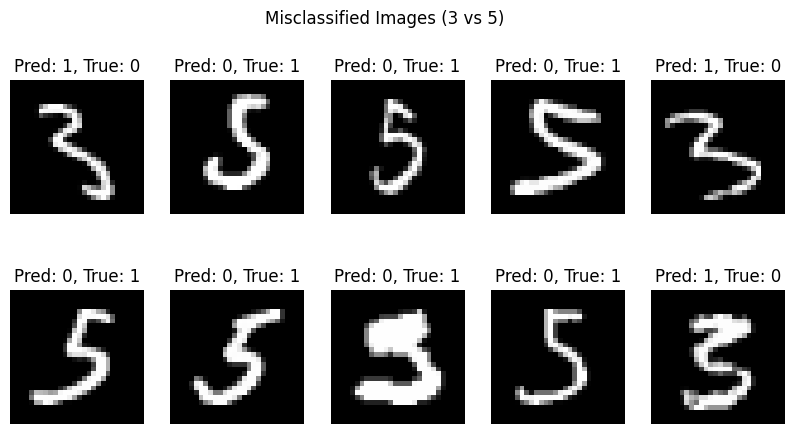

In [26]:
y_pred_35 = decision_function(X_35, weights_35, bias_35)
misclassified_idx_35 = np.where(y_pred_35 != y_35_bin)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"Pred: {y_pred_35[idx]}, True: {y_35_bin[idx]}")
        ax.axis('off')
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

### Conclusion (3 vs 5 Classification)

1. The perceptron achieved an accuracy of approximately 0.9869.  
2. Misclassified images reveal that some digits are ambiguous, and the linear decision boundary of the perceptron cannot perfectly separate all examples.  
3. This confirms a limitation of the perceptron: it works well for **linearly separable data**, but struggles with more complex patterns like 3 vs 5.  
4. To improve performance on such tasks, **multi-layer perceptrons (MLPs) or other non-linear classifiers** should be used.  